# Exercise 15
**Cristina Correa - 1819211867**


Now we can try a different dataset and test the whole
pipeline on it. The dataset for this exercise is iris dataset: https://archive.ics.uci.edu/dataset/53/iris. You can import it as follows:

=== Logistic Regression ===
Accuracy: 0.9667
ROC AUC: 0.9948777668075914
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


=== Support Vector Machine ===
Accuracy: 1.0000
ROC AUC: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

C

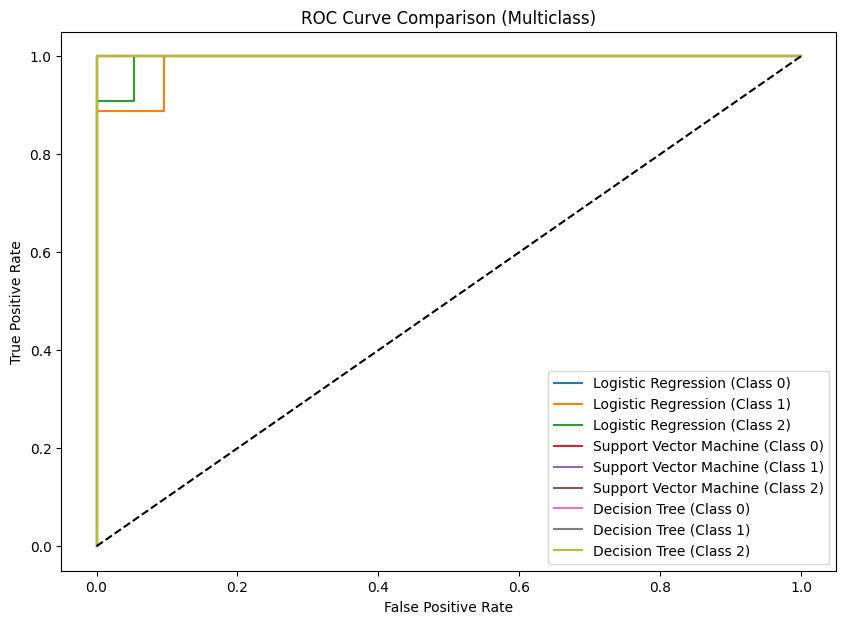

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.datasets import load_iris
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier


data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

y_binarized = label_binarize(y, classes=np.unique(y))
n_classes = y_binarized.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": OneVsRestClassifier(
        LogisticRegression(random_state=0, max_iter=200)
    ),
    "Support Vector Machine": SVC(probability=True, random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
}

results = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = (
        model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
    )

    accuracy = accuracy_score(y_test, y_pred)
    classification = classification_report(y_test, y_pred, target_names=target_names)
    cm = confusion_matrix(y_test, y_pred)

    if y_pred_proba is not None:
        y_test_binarized = label_binarize(y_test, classes=np.unique(y))
        roc_auc = roc_auc_score(
            y_test_binarized, y_pred_proba, average="macro", multi_class="ovr"
        )
    else:
        roc_auc = "N/A (No probability output)"

    results[model_name] = {
        "Accuracy": accuracy,
        "Classification Report": classification,
        "Confusion Matrix": cm,
        "ROC AUC": roc_auc,
    }

    print(f"=== {model_name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc}")
    print("Classification Report:")
    print(classification)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

plt.figure(figsize=(10, 7))
for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)
        fpr, tpr = {}, {}
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(
                label_binarize(y_test, classes=np.unique(y))[:, i], y_pred_proba[:, i]
            )
            plt.plot(fpr[i], tpr[i], label=f"{model_name} (Class {i})")
    else:
        print(f"ROC curve not plotted for {model_name} (no probability output).")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()